In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import codecs
import os
from collections import Counter

In [2]:
DATA_ROOT = "/home/112401002/Documents/Sem 5/Introduction to Machine Learning DS3010/Lab 4/20news-bydate"
TRAIN_DIR = os.path.join(DATA_ROOT, "20news-bydate-train")
TEST_DIR = os.path.join(DATA_ROOT, "20news-bydate-test")
print(sorted(os.listdir(TRAIN_DIR))) # should list the 20 class folders


with open("stopwords.txt", "r") as f:
    stopwords = set(f.read().split())

docs = {}
for c in os.listdir(TRAIN_DIR):
    docs[c] = {}
    for file in os.listdir(os.path.join(TRAIN_DIR, c)):
        # print(f"Processing {file}")
        docs[c][file] = []
        with codecs.open(os.path.join(TRAIN_DIR, c, file), "r", encoding='utf-8',errors='ignore') as f:
            text = f.read()
            text = text.split("\n\n", 1)[1]
            words = text.lower().split()
            for word in words:
                word.strip(".,!?()[]:;")
                if word.isalpha() and len(word) > 1 and word not in stopwords:
                    docs[c][file].append(word)



docs_test = {}
for c in os.listdir(TEST_DIR):
    docs_test[c] = {}
    for file in os.listdir(os.path.join(TEST_DIR, c)):
        docs_test[c][file] = []
        with codecs.open(os.path.join(TEST_DIR, c, file), "r", encoding='utf-8',errors='ignore') as f:
            text = f.read()
            text = text.split("\n\n", 1)[1]
            words = text.lower().split()
            for word in words:
                word.strip(".,!?()[]:;")
                if word.isalpha() and len(word) > 1 and word not in stopwords:
                    docs_test[c][file].append(word)

['alt.atheism', 'comp.graphics', 'comp.os.ms-windows.misc', 'comp.sys.ibm.pc.hardware', 'comp.sys.mac.hardware', 'comp.windows.x', 'misc.forsale', 'rec.autos', 'rec.motorcycles', 'rec.sport.baseball', 'rec.sport.hockey', 'sci.crypt', 'sci.electronics', 'sci.med', 'sci.space', 'soc.religion.christian', 'talk.politics.guns', 'talk.politics.mideast', 'talk.politics.misc', 'talk.religion.misc']


In [3]:
class comp:
    def __init__(self, docs):
        self.classes = ["comp.graphics","comp.os.ms-windows.misc","comp.sys.ibm.pc.hardware","comp.sys.mac.hardware","comp.windows.x"]
        self.docs = {}
        for c in self.classes:
            self.docs = self.docs | docs[c]
        self.name = "comp"
        
class rec:
    def __init__(self, docs):
        self.classes = ["rec.autos","rec.motorcycles","rec.sport.baseball","rec.sport.hockey"]
        self.docs = {}
        for c in self.classes:
            self.docs = self.docs | docs[c]
        self.name = "rec"

class sci:
    def __init__(self, docs):
        self.classes = ["sci.crypt","sci.electronics","sci.med","sci.space"]
        self.docs = {}
        for c in self.classes:
            self.docs = self.docs | docs[c]
        self.name = "sci"

class politics:
    def __init__(self, docs):
        self.classes = ["talk.politics.misc","talk.politics.guns","talk.politics.mideast"]
        self.docs = {}
        for c in self.classes:
            self.docs = self.docs | docs[c]
        self.name = "politics"

class religion:
    def __init__(self, docs):
        self.classes = ["talk.religion.misc","alt.atheism","soc.religion.christian"]
        self.docs = {}
        for c in self.classes:
            self.docs = self.docs | docs[c]
        self.name = "religion"

Comp = comp(docs)
Rec = rec(docs)
Sci = sci(docs)
Politics = politics(docs)
Religion = religion(docs)

Tasks: 
1.  Naive Bayes Classification  (3 Marks) 
   
A. Train a naive Bayes classifier for each of the following tasks: (You may use your earlier implementation)  
  (i) sci.med vs sci.space  
  (ii) comp.sys.ibm.pc.hardware vs comp.sys.mac.hardware  
  (iii) politics vs religion  
  (iv) politics vs sci  
  (v) politics vs rec vs religion vs sci  



B. Evaluate the classifiers on the respective test datasets and report precision, recall, F1 
score, along with the confusion matrix.

In [4]:
def predict(words):
    P_k_t = {}
    n_t_w = Counter(words)
    
    for c in compare:
        P_k_t[c] = np.log(P_k[c])
        denom = total_words_in_class[c] + len(v) * alpha
        unseen_logprob = np.log(alpha / denom)
        
        for w, count in n_t_w.items():
            if w not in v:
                continue
            if w in P_w_k[c]:
                P_k_t[c] += np.log(P_w_k[c][w]) * count
            else:
                P_k_t[c] += unseen_logprob * count

    return max(P_k_t, key=P_k_t.get)



for compare in [["sci.med", "sci.space"], ["comp.sys.ibm.pc.hardware","comp.sys.mac.hardware"]]:
    alpha = 1
    total_docs = 0
    total_words_in_class = {}
    v = set()
    P_k = {}
    P_w_k = {}
    print(compare)

    for c in compare:
        total_docs += len(docs[c])
        total_words_in_class[c] = 0
        P_w_k[c] = {}

    for c in compare:
        P_k[c] = len(docs[c])/total_docs
        for f in docs[c]:
            total_words_in_class[c] += len(docs[c][f])

    for c in compare:
        seen_class = set()
        for f in docs[c]:
            for w in set(docs[c][f]):
                if w not in v:
                    v.add(w)
                if w not in seen_class:
                    seen_class.add(w)
                    P_w_k[c][w] = alpha
                P_w_k[c][w] += docs[c][f].count(w)

    for c in P_w_k:
        for w in P_w_k[c]:
            P_w_k[c][w] /= total_words_in_class[c] + len(v)*alpha



    confMatrix = np.zeros((len(compare), len(compare)))
    for c in compare:
        for f in docs_test[c]:
            predicted = predict(docs_test[c][f])
            true = c
            confMatrix[compare.index(predicted), compare.index(true)] += 1

    print(confMatrix)

    precision = {}
    for c in compare:
        precision[c] = confMatrix[compare.index(c), compare.index(c)]/confMatrix[compare.index(c), :].sum()
        print(f"Precision({c}): {precision[c]}")

    recall = {}
    for c in compare:
        recall[c] = confMatrix[compare.index(c), compare.index(c)]/confMatrix[:, compare.index(c)].sum()
        print(f"Recall({c}): {recall[c]}")

    f1 = {}
    for c in compare:
        f1[c] = 2*precision[c]*recall[c]/(precision[c]+recall[c])
        print(f"F1 Score({c}): {f1[c]}")

    accuracy = np.trace(confMatrix)/np.sum(confMatrix)
    print(f"Accuracy: {accuracy}")
    print()

['sci.med', 'sci.space']
[[379.  13.]
 [ 17. 381.]]
Precision(sci.med): 0.9668367346938775
Precision(sci.space): 0.957286432160804
Recall(sci.med): 0.9570707070707071
Recall(sci.space): 0.9670050761421319
F1 Score(sci.med): 0.9619289340101522
F1 Score(sci.space): 0.962121212121212
Accuracy: 0.9620253164556962

['comp.sys.ibm.pc.hardware', 'comp.sys.mac.hardware']
[[330.  48.]
 [ 62. 337.]]
Precision(comp.sys.ibm.pc.hardware): 0.873015873015873
Precision(comp.sys.mac.hardware): 0.8446115288220551
Recall(comp.sys.ibm.pc.hardware): 0.8418367346938775
Recall(comp.sys.mac.hardware): 0.8753246753246753
F1 Score(comp.sys.ibm.pc.hardware): 0.8571428571428572
F1 Score(comp.sys.mac.hardware): 0.8596938775510206
Accuracy: 0.8584298584298584



In [5]:
def predict(words):
    P_k_t = {}
    n_t_w = Counter(words)
    
    for c in compare:
        P_k_t[c.name] = np.log(P_k[c.name])
        denom = total_words_in_class[c.name] + len(v) * alpha
        unseen_logprob = np.log(alpha / denom)
        
        for w, count in n_t_w.items():
            if w not in v:
                continue
            if w in P_w_k[c.name]:
                P_k_t[c.name] += np.log(P_w_k[c.name][w]) * count
            else:
                P_k_t[c.name] += unseen_logprob * count

    return max(P_k_t, key=P_k_t.get)



for compare in [[Politics, Religion], [Politics, Sci], [Politics, Rec, Religion, Sci]]:
    alpha = 1
    total_docs = 0
    total_words_in_class = {}
    v = set()
    P_k = {}
    P_w_k = {}
    print(compare)

    for c in compare:
        total_docs += len(c.docs)
        total_words_in_class[c.name] = 0
        P_w_k[c.name] = {}

    for c in compare:
        P_k[c.name] = len(c.docs)/total_docs
        for f in c.docs:
            total_words_in_class[c.name] += len(c.docs[f])

    for c in compare:
        seen_class = set()
        for f in c.docs:
            for w in set(c.docs[f]):
                if w not in v:
                    v.add(w)
                if w not in seen_class:
                    seen_class.add(w)
                    P_w_k[c.name][w] = alpha
                P_w_k[c.name][w] += c.docs[f].count(w)

    for c in P_w_k:
        for w in P_w_k[c]:
            P_w_k[c][w] /= total_words_in_class[c] + len(v)*alpha



    confMatrix = np.zeros((len(compare), len(compare)))
    for cl in compare:
        for c in cl.classes:
            for f in docs_test[c]:
                predicted = predict(docs_test[c][f])
                true = cl.name
                confMatrix[[cl.name for cl in compare].index(predicted), [cl.name for cl in compare].index(true)] += 1

    print(confMatrix)

    precision = {}
    for c in [cl.name for cl in compare]:
        precision[c] = confMatrix[[cl.name for cl in compare].index(c), [cl.name for cl in compare].index(c)]/confMatrix[[cl.name for cl in compare].index(c), :].sum()
        print(f"Precision({c}): {precision[c]}")

    recall = {}
    for c in [cl.name for cl in compare]:
        recall[c] = confMatrix[[cl.name for cl in compare].index(c), [cl.name for cl in compare].index(c)]/confMatrix[:, [cl.name for cl in compare].index(c)].sum()
        print(f"Recall({c}): {recall[c]}")

    f1 = {}
    for c in [cl.name for cl in compare]:
        f1[c] = 2*precision[c]*recall[c]/(precision[c]+recall[c])
        print(f"F1 Score({c}): {f1[c]}")

    accuracy = np.trace(confMatrix)/np.sum(confMatrix)
    print(f"Accuracy: {accuracy}")
    print()

[<__main__.politics object at 0x7f75fbfd1eb0>, <__main__.religion object at 0x7f75fdc92220>]
[[948.  88.]
 [102. 880.]]
Precision(politics): 0.915057915057915
Precision(religion): 0.8961303462321792
Recall(politics): 0.9028571428571428
Recall(religion): 0.9090909090909091
F1 Score(politics): 0.9089165867689357
F1 Score(religion): 0.9025641025641025
Accuracy: 0.9058473736372646

[<__main__.politics object at 0x7f75fbfd1eb0>, <__main__.sci object at 0x7f75fbfd1e80>]
[[ 999.   95.]
 [  51. 1484.]]
Precision(politics): 0.9131627056672761
Precision(sci): 0.9667752442996743
Recall(politics): 0.9514285714285714
Recall(sci): 0.9398353388220393
F1 Score(politics): 0.9319029850746269
F1 Score(sci): 0.9531149646756583
Accuracy: 0.9444655762647395

[<__main__.politics object at 0x7f75fbfd1eb0>, <__main__.rec object at 0x7f75fbfd1f10>, <__main__.religion object at 0x7f75fdc92220>, <__main__.sci object at 0x7f75fbfd1e80>]
[[ 911.   47.   79.   72.]
 [  17. 1439.   10.   54.]
 [  77.   23.  840.   43

C. Interpret the classifiers and explain in your own words the behavior of these 
classifiers

sci.med vs sci.space had a very high accuracy, because space and medicine have very little words in common, leading to ease in distinguishing them. The output of ibm vs mac hardware had the least accuracy among the five, because there are a lot of common words between the two, so distinguishing them was harder. The other three had varying accuracies, in a range from 88% to 94%. When grouping politics, sci, and religion, the accuracy increased to 90% and above, because there is less overlap between broad, domain-specific words. However, when deviating from binary and moving to multiple classes, the accuracy decreases as there are more classes to distinguish between.

2.  Logistic regression (3 Marks) 
A. Represent each document as a TF-IDF vector. You are supposed to write your own 
TF-IDF Vectorizer. 

In [6]:
total_docs = 0
word_freq = {}
for c in docs:
    total_docs += len(docs[c])
    for f in docs[c]:
        for w in set(docs[c][f]):
            if w not in word_freq:
                word_freq[w] = 0
            word_freq[w] += 1

v = word_freq.keys()

idf = {}
for w in v:
    idf[w] = np.log(total_docs / word_freq[w])

In [7]:
def vectorize(doc):
    tf = {}
    tf_idf = []
    counts = Counter(doc)
    for w in v:
        if w in counts:
            tf[w] = counts[w] / len(doc)
        else:
            tf[w] = 0
        tf_idf.append(tf[w] * idf[w])
    return tf_idf

B. Train Logistic Regression classifiers on the tasks mentioned in Step-1 using 
TF-IDF-based representation of documents

In [8]:
docs_labels = []
docs_matrix = np.zeros((total_docs, len(v)))
for c in docs:
    for f in docs[c]:
        docs_labels.append(c)
        docs_matrix[len(docs_labels)-1] = vectorize(docs[c][f])

print(docs_matrix)
print(docs_labels)

[[0.52059341 0.31198906 0.27755415 ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 ...
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.27452342]]
['rec.motorcycles', 'rec.motorcycles', 'rec.motorcycles', 'rec.motorcycles', 'rec.motorcycles', 'rec.motorcycles', 'rec.motorcycles', 'rec.motorcycles', 'rec.motorcycles', 'rec.motorcycles', 'rec.motorcycles', 'rec.motorcycles', 'rec.motorcycles', 'rec.motorcycles', 'rec.motorcycles', 'rec.motorcycles', 'rec.motorcycles', 'rec.motorcycles', 'rec.motorcycles', 'rec.motorcycles', 'rec.motorcycles', 'rec.motorcycles', 'rec.motorcycles', 'rec.motorcycles', 'rec.motorcycles', 'rec.motorcycles', 'rec.motorcycles', 'rec.motorcycles', 'rec.motorcycles', 'rec

In [9]:
from sklearn.linear_model import LogisticRegression

multi_logreg = LogisticRegression(max_iter=1000)
multi_logreg.fit(docs_matrix, docs_labels)

LogisticRegression(max_iter=1000)

C. Evaluate the classifiers on the respective test datasets and report precision, recall, F1 
score, along with the confusion matrix.

In [10]:
total_test_docs = 0
for c in docs_test:
    total_test_docs += len(docs_test[c])

test_docs_labels = []
test_docs_matrix = np.zeros((total_test_docs, len(v)))
for c in docs_test:
    for f in docs_test[c]:
        test_docs_labels.append(c)
        test_docs_matrix[len(test_docs_labels)-1] = vectorize(docs_test[c][f])

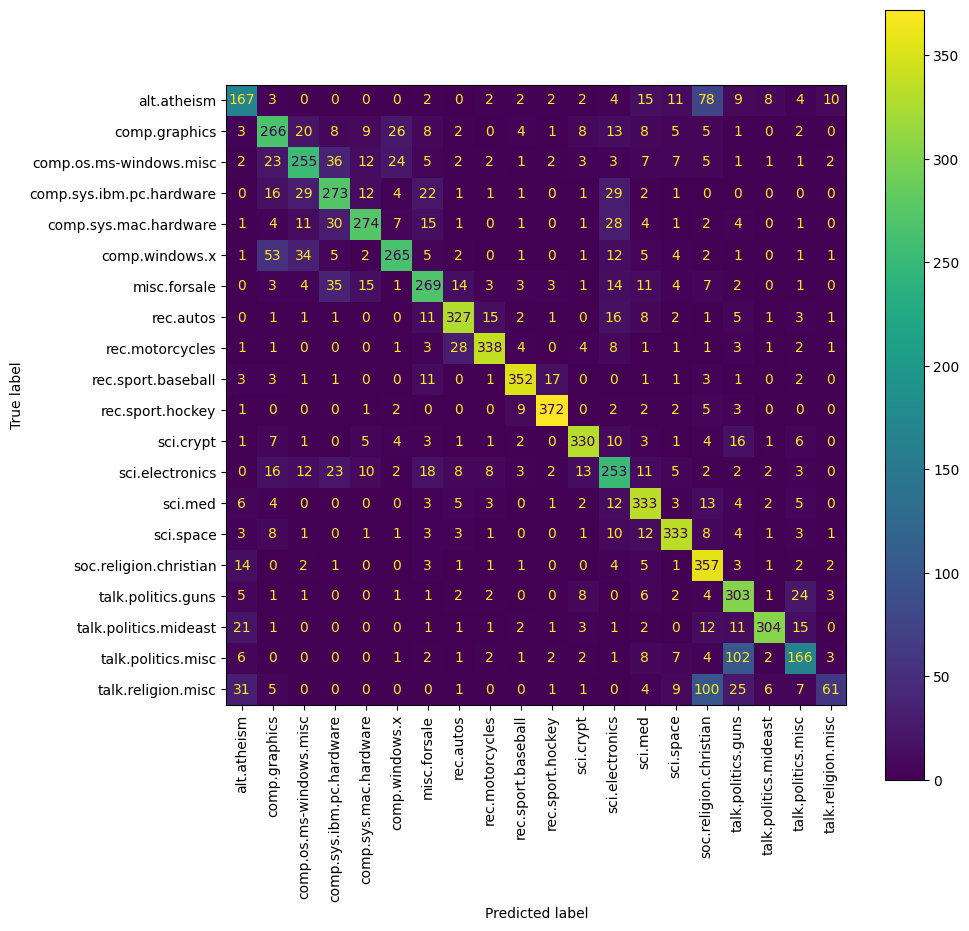

Accuracy: 0.7432288900690388
Precision: 0.7432288900690388
Recall: 0.7432288900690388
F1 Score: 0.7432288900690388


In [11]:
import sklearn.metrics as metrics

y_pred = multi_logreg.predict(test_docs_matrix)
confMatrix = metrics.confusion_matrix(test_docs_labels, y_pred)
class_names = sorted(list(set(test_docs_labels))) 
disp = metrics.ConfusionMatrixDisplay(confMatrix, display_labels=class_names).plot()
disp.figure_.set_size_inches(10, 10)
plt.xticks(rotation = 90)
plt.show()

print(f"Accuracy: {metrics.accuracy_score(test_docs_labels, y_pred)}")
print(f"Precision: {metrics.precision_score(test_docs_labels, y_pred, average='micro')}")
print(f"Recall: {metrics.recall_score(test_docs_labels, y_pred, average='micro')}")
print(f"F1 Score: {metrics.f1_score(test_docs_labels, y_pred, average='micro')}")

D. Interpret the classifiers and explain in your own words the behavior of these 
classifiers 

The accuracy of the logistic regression model was only 74.3%. We can see from the confusion matrix that the number of confusions increases around the comp categories and sci.electronics as they have many words in common.

3. Compare the performance of naive Bayes and Logistic Regression. Considering their underlying assumptions, explain the behavior of the classifiers across the tasks (4 Marks)

The accuracy of the Naive Bayes Classifier is higher than the accuracy of the Logistic Regression Classifier. This is because the Naive Bayes Classifier looks at the words and maps them to categories while the Logistic Regression Classifier sets up direct mathematical cuts between the categories. The TF-IDF Vectors for the Logistic Regression are very noisy due to the similarity between classes like the comp labels and sci.electronics, leading to reduced accuracy. The time taken for training the Logistic Regression Classifier was much more than the time taken for the Naive Bayes Classifier. This is because the training time for the Logistic Regression Classifier is proportional to the number of samples in the dataset (total number of documents in the training set).